# 3D Gaussian Splatting Ablation Study
## Impact of Spatial Camera Distribution on Novel View Synthesis

**Hypothesis:** Clustered camera distributions lead to geometry collapse in unobserved regions.

---

## Part 1: Environment Setup

In [1]:
# Cell 1: Clone 3DGS Repository
!git clone https://github.com/graphdeco-inria/gaussian-splatting --recursive

Cloning into 'gaussian-splatting'...
remote: Enumerating objects: 1053, done.
remote: Total 1053 (delta 0), reused 0 (delta 0), pack-reused 1053 (from 1)
Receiving objects: 100% (1053/1053), 78.71 MiB | 36.80 MiB/s, done.
Resolving deltas: 100% (595/595), done.
Submodule 'SIBR_viewers' (https://gitlab.inria.fr/sibr/sibr_core.git) registered for path 'SIBR_viewers'
Submodule 'submodules/diff-gaussian-rasterization' (https://github.com/graphdeco-inria/diff-gaussian-rasterization.git) registered for path 'submodules/diff-gaussian-rasterization'
Submodule 'submodules/fused-ssim' (https://github.com/rahul-goel/fused-ssim.git) registered for path 'submodules/fused-ssim'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/kaggle/working/gaussian-splatting/SIBR_viewers'...
remote: Enumerating objects: 3293, done.        
remote: Counting objects: 100% (322/322), done.        
remote: Compressing objects: 1

In [2]:
# Cell 2: Install Dependencies
!pip install plyfile tqdm
!pip install gaussian-splatting/submodules/simple-knn/
!pip install gaussian-splatting/submodules/diff-gaussian-rasterization/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.8 MB/s eta 0:00:00
Processing ./gaussian-splatting/submodules/simple-knn
  Preparing metadata (setup.py) ... done
  Created wheel for simple_knn: filename=simple_knn-0.0.0-cp312-cp312-linux_x86_64.whl size=3552489 sha256=e52cccea9f3877edfc9ad05daebeef062dde2c5cbd64484a8ffb1bbc98c93e38
  Stored in directory: /root/.cache/pip/wheels/ca/30/df/7f4f362d12edead48c699acde5962cbb06ca05033b9d970934
Successfully built simple_knn
Processing ./gaussian-splatting/submodules/diff-gaussian-rasterization
  Preparing metadata (setup.py) ... done
  Created wheel for diff_gaussian_rasterization: filename=diff_gaussian_rasterization-0.0.0-cp312-cp312-linux_x86_64.whl size=3812359 sha256=5ce6350affead6ce1c8048e1d553a08f55cace3890dae123211b619247e07221
  Stored in directory: /root/.cache/pip/wheels/ba/99/d3/014520068aca8c2e8bdc358ca774581380cadb65788559b3ea
Successfully built diff_gaussian_rasterization


In [3]:
# ==============================================================================
# Cell 3: MASTER SETUP & GLOBAL HELPERS
# ==============================================================================
# All imports and global utilities are centralized here.
# Do NOT import these modules again in lower cells.
# ==============================================================================

import os
import sys
import math
import json
import shutil
import struct
import subprocess
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------------------------------------
# Global Path Configuration
# ------------------------------------------------------------------------------
GS_ROOT = '/kaggle/working/gaussian-splatting'
DATASET_ROOT = '/kaggle/input/datasets/thnhdg/testing'
WORKING_BASE = '/kaggle/working/datasets'
OUTPUT_BASE = '/kaggle/working/output'

# Add 3DGS to Python path (do this ONCE here, nowhere else)
sys.path.insert(0, GS_ROOT)

# Create working directories
os.makedirs(WORKING_BASE, exist_ok=True)
os.makedirs(OUTPUT_BASE, exist_ok=True)

# ------------------------------------------------------------------------------
# Global Helper: Load Camera Centers from COLMAP
# ------------------------------------------------------------------------------
# This function is used by BOTH the subsampling logic AND the plotting logic.
# Centralizing it here fixes the DRY violation.
# ------------------------------------------------------------------------------
from scene.colmap_loader import read_extrinsics_binary, qvec2rotmat

def load_camera_centers_dict(sparse_dir):
    """
    Extract 3D world coordinates of camera centers from COLMAP binary files.
    
    Args:
        sparse_dir: Path to the sparse folder (containing '0/images.bin')
    
    Returns:
        dict: Mapping from image filename to 3D world coordinate [x, y, z]
    """
    images_bin_path = os.path.join(sparse_dir, '0', 'images.bin')
    cam_extrinsics = read_extrinsics_binary(images_bin_path)
    
    centers = {}
    for cam_id, cam in cam_extrinsics.items():
        R = qvec2rotmat(cam.qvec)
        T = np.array(cam.tvec)
        # World-space camera center: C = -R^T * T
        centers[cam.name] = -np.dot(R.T, T)
    
    return centers

print("Master setup complete.")
print(f"  GS_ROOT: {GS_ROOT}")
print(f"  DATASET_ROOT: {DATASET_ROOT}")
print(f"  WORKING_BASE: {WORKING_BASE}")
print(f"  OUTPUT_BASE: {OUTPUT_BASE}")

Master setup complete.
  GS_ROOT: /kaggle/working/gaussian-splatting
  DATASET_ROOT: /kaggle/input/datasets/thnhdg/testing
  WORKING_BASE: /kaggle/working/datasets
  OUTPUT_BASE: /kaggle/working/output


In [4]:
# Cell 4: Verify 3DGS Imports
from scene import Scene
from gaussian_renderer import render
from utils.general_utils import safe_state
import diff_gaussian_rasterization
import simple_knn

print("3DGS core imports: OK")
print("CUDA submodules: OK")

3DGS core imports: OK
CUDA submodules: OK


## Part 2: Dataset Discovery & Validation

In [5]:
# Cell 5: Scan Available Scenes
scene_dirs = ['360_v2', '360_extra_scenes']

scenes = []
scene_base_map = {}  # maps scene name -> parent folder path

for subdir in scene_dirs:
    subdir_path = os.path.join(DATASET_ROOT, subdir)
    if not os.path.exists(subdir_path):
        print(f"Warning: {subdir} not found, skipping")
        continue
    for d in sorted(os.listdir(subdir_path)):
        full_path = os.path.join(subdir_path, d)
        if os.path.isdir(full_path):
            scenes.append(d)
            scene_base_map[d] = subdir_path

print(f"Found {len(scenes)} scenes:")
for scene in scenes:
    scene_path = os.path.join(scene_base_map[scene], scene)
    contents = os.listdir(scene_path)
    print(f"  {scene}/ ({scene_base_map[scene].split('/')[-1]}) -> {contents}")

Found 9 scenes:
  bicycle/ (360_v2) -> ['images_8', 'images_4', 'images_2', 'images', 'sparse', 'poses_bounds.npy']
  bonsai/ (360_v2) -> ['images_8', 'images_4', 'images_2', 'images', 'sparse', 'poses_bounds.npy']
  counter/ (360_v2) -> ['images_8', 'images_4', 'images_2', 'images', 'sparse', 'poses_bounds.npy']
  garden/ (360_v2) -> ['images_8', 'images_4', 'images_2', 'images', 'sparse', 'poses_bounds.npy']
  kitchen/ (360_v2) -> ['images_8', 'images_4', 'images_2', 'images', 'sparse', 'poses_bounds.npy']
  room/ (360_v2) -> ['images_8', 'images_4', 'images_2', 'images', 'sparse', 'poses_bounds.npy']
  stump/ (360_v2) -> ['images_8', 'images_4', 'images_2', 'images', 'sparse', 'poses_bounds.npy']
  flowers/ (360_extra_scenes) -> ['images_8', 'images_4', 'images_2', 'images', 'sparse', 'poses_bounds.npy']
  treehill/ (360_extra_scenes) -> ['images_8', 'images_4', 'images_2', 'images', 'sparse', 'poses_bounds.npy']


In [6]:
# Cell 6: Verify COLMAP Files
required_files = ['cameras.bin', 'images.bin', 'points3D.bin']

print("COLMAP file check:")
all_ok = True

for scene in scenes:
    sparse_path = os.path.join(scene_base_map[scene], scene, 'sparse', '0')
    
    if not os.path.exists(sparse_path):
        print(f"  [MISSING] {scene}: sparse/0/ folder not found")
        all_ok = False
        continue
    
    present = os.listdir(sparse_path)
    missing = [f for f in required_files if f not in present]
    
    if missing:
        print(f"  [MISSING] {scene}: {missing}")
        all_ok = False
    else:
        print(f"  [OK] {scene}: all COLMAP files present")

if all_ok:
    print("\nAll scenes have complete COLMAP data.")
else:
    print("\nSome scenes have missing files!")

COLMAP file check:
  [OK] bicycle: all COLMAP files present
  [OK] bonsai: all COLMAP files present
  [OK] counter: all COLMAP files present
  [OK] garden: all COLMAP files present
  [OK] kitchen: all COLMAP files present
  [OK] room: all COLMAP files present
  [OK] stump: all COLMAP files present
  [OK] flowers: all COLMAP files present
  [OK] treehill: all COLMAP files present

All scenes have complete COLMAP data.


In [7]:
# Cell 7: Check Image Folders
print("Image folder check:")

for scene in scenes:
    scene_path = os.path.join(scene_base_map[scene], scene)
    
    for folder_name in ['images', 'images_2', 'images_4', 'images_8']:
        img_dir = os.path.join(scene_path, folder_name)
        if os.path.exists(img_dir):
            count = len([
                f for f in os.listdir(img_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
            print(f"  [OK] {scene}: '{folder_name}/' -> {count} images")
            break
    else:
        print(f"  [MISSING] {scene}: no images folder found")

Image folder check:
  [OK] bicycle: 'images/' -> 194 images
  [OK] bonsai: 'images/' -> 292 images
  [OK] counter: 'images/' -> 240 images
  [OK] garden: 'images/' -> 185 images
  [OK] kitchen: 'images/' -> 279 images
  [OK] room: 'images/' -> 311 images
  [OK] stump: 'images/' -> 125 images
  [OK] flowers: 'images/' -> 173 images
  [OK] treehill: 'images/' -> 141 images


In [8]:
# Cell 8: Point Cloud Size Check
print("Point cloud size check:")

for scene in scenes:
    p3d_path = os.path.join(scene_base_map[scene], scene, 'sparse', '0', 'points3D.bin')
    if os.path.exists(p3d_path):
        size_kb = os.path.getsize(p3d_path) / 1024
        status = "[OK]" if size_kb > 100 else "[WARN]"
        print(f"  {status} {scene}: points3D.bin -> {size_kb:.1f} KB")
    else:
        print(f"  [MISSING] {scene}: points3D.bin not found")

Point cloud size check:
  [OK] bicycle: points3D.bin -> 4691.2 KB
  [OK] bonsai: points3D.bin -> 24317.3 KB
  [OK] counter: points3D.bin -> 15494.2 KB
  [OK] garden: points3D.bin -> 14487.7 KB
  [OK] kitchen: points3D.bin -> 28106.8 KB
  [OK] room: points3D.bin -> 13268.6 KB
  [OK] stump: points3D.bin -> 2696.1 KB
  [OK] flowers: points3D.bin -> 3289.6 KB
  [OK] treehill: points3D.bin -> 4769.3 KB


## Part 3: Ablation Configuration

In [9]:
# Conditions cell
target_scenes = ['garden']

conditions = [
    ("100pct_baseline",       1.00, "baseline"),
    ("75pct_uniform",         0.75, "uniform"),
    ("50pct_uniform",         0.50, "uniform"),
    ("25pct_uniform",         0.25, "uniform"),
    ("50pct_clustered_front", 0.50, "clustered_front"),
    ("50pct_clustered_back",  0.50, "clustered_back"),
]

print(f"Target scenes: {target_scenes}")
print(f"Conditions: {[c[0] for c in conditions]}")

Target scenes: ['garden']
Conditions: ['100pct_baseline', '75pct_uniform', '50pct_uniform', '25pct_uniform', '50pct_clustered_front', '50pct_clustered_back']


In [10]:
# Cell 10: Dataset Structure Summary
print("=" * 55)
print("DATASET STRUCTURE SUMMARY")
print("=" * 55)

for scene in target_scenes:
    scene_path = os.path.join(scene_base_map[scene], scene)
    img_dir = os.path.join(scene_path, 'images_4')
    sparse_dir = os.path.join(scene_path, 'sparse', '0')
    
    img_count = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    test_count = img_count // 8
    train_count = img_count - test_count
    p3d_size = os.path.getsize(os.path.join(sparse_dir, 'points3D.bin')) / 1024
    
    print(f"\n  Scene      : {scene}")
    print(f"  Images     : {img_count} total ({train_count} train / {test_count} test)")
    print(f"  Resolution : images_4 (quarter-res)")
    print(f"  Point cloud: {p3d_size:.1f} KB")

DATASET STRUCTURE SUMMARY

  Scene      : garden
  Images     : 185 total (162 train / 23 test)
  Resolution : images_4 (quarter-res)
  Point cloud: 14487.7 KB


## Part 4: Subsampled Dataset Generation

In [11]:
# Cell 11: Subsampling Function
def generate_subsampled_dataset(scene, condition_name, fraction, strategy):
    """
    Generate a subsampled dataset with symlinked images.
    
    Strategies:
        - 'baseline': Keep all images
        - 'uniform': Evenly space across the sequence
        - 'clustered': Select spatially nearest images to a computed anchor
    """
    # Source paths
    src_scene_dir = os.path.join(scene_base_map[scene], scene)
    src_images_dir = os.path.join(src_scene_dir, 'images_4')
    src_sparse_dir = os.path.join(src_scene_dir, 'sparse', '0')

    # Target paths
    target_scene_dir = os.path.join(WORKING_BASE, f"{scene}_{condition_name}")
    target_images_dir = os.path.join(target_scene_dir, 'images_4')

    # Clean and recreate
    if os.path.exists(target_scene_dir):
        shutil.rmtree(target_scene_dir)
    os.makedirs(target_images_dir, exist_ok=True)

    # Copy COLMAP sparse folder
    target_sparse_dir = os.path.join(target_scene_dir, 'sparse', '0')
    os.makedirs(os.path.join(target_scene_dir, 'sparse'), exist_ok=True)
    shutil.copytree(src_sparse_dir, target_sparse_dir)

    # Gather all images
    all_images = sorted([
        f for f in os.listdir(src_images_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    total_imgs = len(all_images)
    target_count = max(1, int(total_imgs * fraction))

    # Select images based on strategy
    if strategy == 'baseline':
        selected_images = all_images
        
    elif strategy == 'uniform':
        # Evenly space indices across the full sequence
        step = total_imgs / target_count
        selected_images = [all_images[int(math.floor(i * step))] for i in range(target_count)]
        
    elif strategy in ('clustered_front', 'clustered_back'):
        cam_centers = load_camera_centers_dict(os.path.join(src_scene_dir, 'sparse'))
        all_centers = np.array(list(cam_centers.values()))
        centroid    = all_centers.mean(axis=0)

        direction_map = {
            'clustered_front': np.array([ 1,  0,  0]),
            'clustered_back':  np.array([-1,  0,  0]),
        }
        target_direction = direction_map[strategy]

        def alignment_score(img_name):
            c   = cam_centers.get(img_name, centroid)
            vec = c - centroid
            n   = np.linalg.norm(vec)
            return np.dot(vec / n, target_direction) if n > 1e-6 else -1

        anchor_center = cam_centers[max(all_images, key=alignment_score)]

        selected_images = sorted(
            all_images,
            key=lambda n: np.linalg.norm(cam_centers.get(n, anchor_center) - anchor_center)
        )[:target_count]
        
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    # Create symlinks
    for img_name in selected_images:
        src = os.path.join(src_images_dir, img_name)
        dest = os.path.join(target_images_dir, img_name)
        os.symlink(src, dest)

    print(f"  {scene} [{condition_name}]: {len(selected_images)}/{total_imgs} images | strategy: {strategy}")
    return target_scene_dir

In [12]:
# Cell 12: Generate All Subsampled Datasets
print("=" * 55)
print("GENERATING SUBSAMPLED DATASETS")
print("=" * 55)

all_generated = []

for scene in target_scenes:
    print(f"\nScene: {scene}")
    for condition_name, fraction, strategy in conditions:
        path = generate_subsampled_dataset(
            scene=scene,
            condition_name=condition_name,
            fraction=fraction,
            strategy=strategy
        )
        all_generated.append((scene, condition_name, path))

print(f"\nDone: {len(all_generated)} dataset folders created.")

GENERATING SUBSAMPLED DATASETS

Scene: garden
  garden [100pct_baseline]: 185/185 images | strategy: baseline
  garden [75pct_uniform]: 138/185 images | strategy: uniform
  garden [50pct_uniform]: 92/185 images | strategy: uniform
  garden [25pct_uniform]: 46/185 images | strategy: uniform
  garden [50pct_clustered_front]: 92/185 images | strategy: clustered_front
  garden [50pct_clustered_back]: 92/185 images | strategy: clustered_back

Done: 6 dataset folders created.


In [13]:
# Cell 13: Verify Generated Datasets
print("=" * 55)
print("VERIFICATION")
print("=" * 55)

required_sparse = ['cameras.bin', 'images.bin', 'points3D.bin']
all_ok = True

for scene, condition_name, folder_path in all_generated:
    images_dir = os.path.join(folder_path, 'images_4')
    sparse_dir = os.path.join(folder_path, 'sparse', '0')

    img_count = len(os.listdir(images_dir))
    sparse_ok = all(os.path.exists(os.path.join(sparse_dir, f)) for f in required_sparse)

    status = "[READY]" if sparse_ok else "[ERROR]"
    print(f"  {status} {scene}_{condition_name:<20} | Images: {img_count}")

    if not sparse_ok:
        all_ok = False

print()
if all_ok:
    print("All folders verified. Ready for training.")
else:
    print("ERROR: Fix missing sparse files before training!")

VERIFICATION
  [READY] garden_100pct_baseline      | Images: 185
  [READY] garden_75pct_uniform        | Images: 138
  [READY] garden_50pct_uniform        | Images: 92
  [READY] garden_25pct_uniform        | Images: 46
  [READY] garden_50pct_clustered_front | Images: 92
  [READY] garden_50pct_clustered_back | Images: 92

All folders verified. Ready for training.


## Part 5: Camera Pose Visualization

Loaded 185 camera poses from COLMAP
  100pct_baseline: 185 poses plotted
  50pct_uniform: 92 poses plotted
  50pct_clustered_front: 92 poses plotted


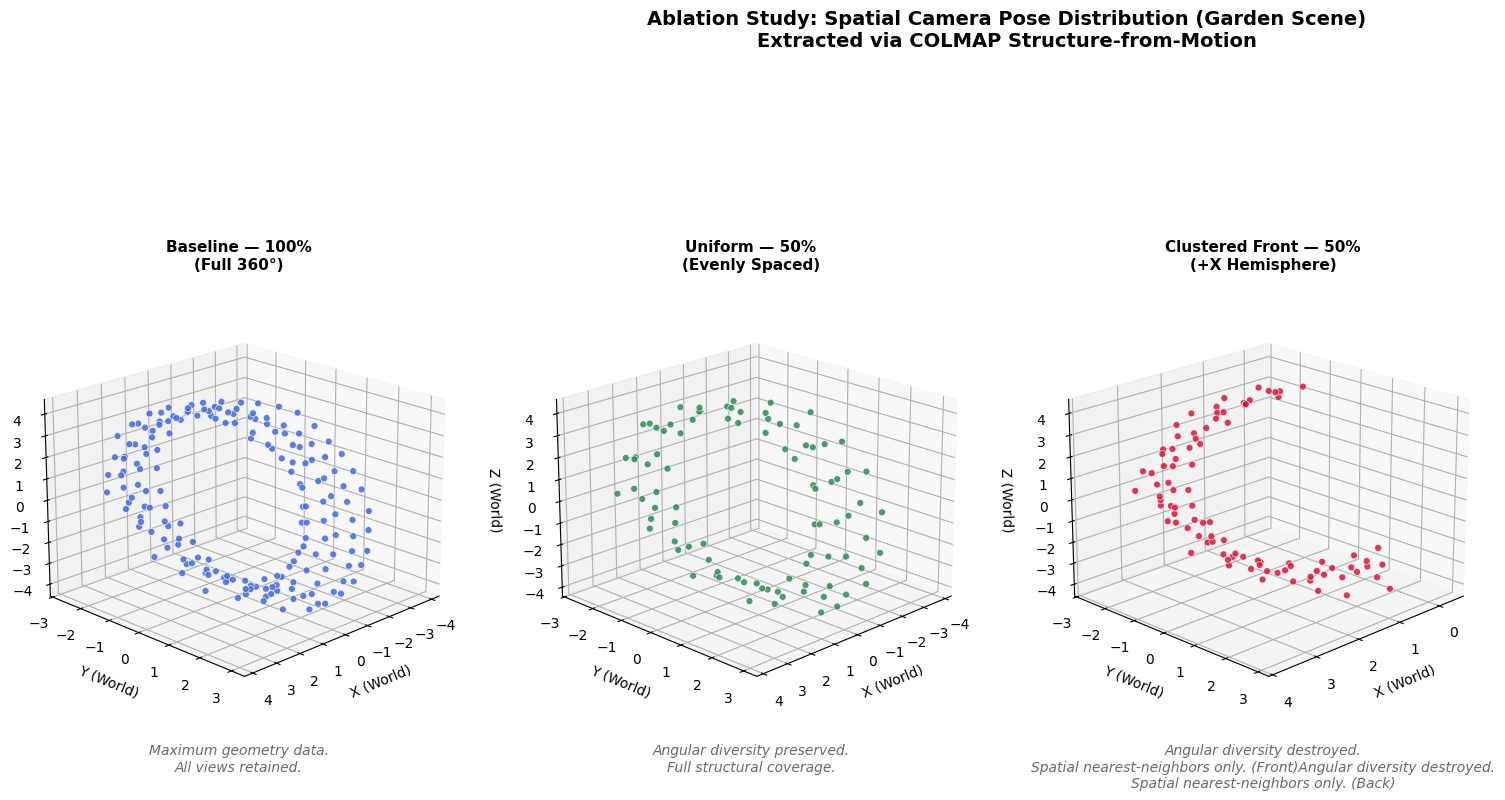

In [14]:
# Cell 14: Plot Camera Pose Distribution
# Uses the GLOBAL load_camera_centers_dict helper (DRY fix)

# Load all poses from baseline
sparse_dir = os.path.join(WORKING_BASE, 'garden_100pct_baseline', 'sparse')
all_poses_dict = load_camera_centers_dict(sparse_dir)
print(f"Loaded {len(all_poses_dict)} camera poses from COLMAP")

# Plot configuration
conds  = ['100pct_baseline', '50pct_uniform', '50pct_clustered_front', '50pct_clustered_back']
colors = ['royalblue', 'seagreen', 'crimson', 'darkorange']
titles = [
    'Baseline — 100%\n(Full 360°)',
    'Uniform — 50%\n(Evenly Spaced)',
    'Clustered Front — 50%\n(+X Hemisphere)',
    'Clustered Back — 50%\n(-X Hemisphere)',
]
descriptions = [
    'Maximum geometry data.\nAll views retained.',
    'Angular diversity preserved.\nFull structural coverage.',
    'Angular diversity destroyed.\nSpatial nearest-neighbors only. (Front)'
    'Angular diversity destroyed.\nSpatial nearest-neighbors only. (Back)'
]

fig = plt.figure(figsize=(20, 9))
fig.suptitle(
    'Ablation Study: Spatial Camera Pose Distribution (Garden Scene)\n'
    'Extracted via COLMAP Structure-from-Motion',
    fontsize=14, fontweight='bold', y=1.02
)

for col, (cond, title, color, desc) in enumerate(zip(conds, titles, colors, descriptions)):
    images_dir = os.path.join(WORKING_BASE, f'garden_{cond}', 'images_4')
    if not os.path.exists(images_dir):
        print(f"Skipping {cond}, directory not found.")
        continue
    
    selected_files = set(os.listdir(images_dir))
    selected_poses = np.array([
        all_poses_dict[fname] for fname in selected_files if fname in all_poses_dict
    ])

    ax = fig.add_subplot(1, 4, col + 1, projection='3d')
    if len(selected_poses) > 0:
        ax.scatter(
            selected_poses[:, 0], selected_poses[:, 1], selected_poses[:, 2],
            c=color, s=25, marker='o', alpha=0.85, edgecolors='white', linewidth=0.5
        )

    ax.set_title(title, fontsize=11, fontweight='bold', pad=14)
    ax.set_xlabel('X (World)', labelpad=6)
    ax.set_ylabel('Y (World)', labelpad=6)
    ax.set_zlabel('Z (World)', labelpad=6)
    ax.view_init(elev=20, azim=45)
    ax.text2D(0.5, -0.05, desc, transform=ax.transAxes,
              fontsize=10, ha='center', va='top', color='dimgray', style='italic')

    print(f"  {cond}: {len(selected_poses)} poses plotted")

plt.tight_layout()
plt.savefig('camera_pose_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Part 6: Patch 3DGS for Subsampled Training

In [15]:
# Cell 15: Apply Dataset Reader Patch
# This patch allows 3DGS to skip missing images gracefully.

patch_file = os.path.join(GS_ROOT, "scene/dataset_readers.py")

with open(patch_file, "r") as f:
    code = f.read()

old_string = "        cam_infos.append(cam_info)"
new_string = "        if os.path.exists(image_path):\n            cam_infos.append(cam_info)"

if "if os.path.exists(image_path):" not in code:
    if old_string in code:
        code = code.replace(old_string, new_string)
        with open(patch_file, "w") as f:
            f.write(code)
        print("[OK] Patch applied successfully.")
    else:
        print("[ERROR] Could not find target line. Dumping cam_infos lines:")
        for i, line in enumerate(code.splitlines()):
            if "cam_infos" in line and "append" in line:
                print(f"  line {i}: {repr(line)}")
else:
    print("[OK] Already patched.")

[OK] Patch applied successfully.


In [16]:
# Cell 16: CRITICAL - Verify Patch Before Training
# This assertion MUST pass or training will fail on subsampled datasets.

patch_path = os.path.join(GS_ROOT, "scene/dataset_readers.py")
with open(patch_path, "r") as f:
    patch_content = f.read()

assert "if os.path.exists(image_path):" in patch_content, \
    "CRITICAL: The dataset_readers.py patch failed to apply! Training will crash."

print("[OK] Patch verification passed. Safe to proceed with training.")

[OK] Patch verification passed. Safe to proceed with training.


## Part 7: Training

In [17]:
# Cell 17: Training Configuration
scene = "garden"

runs = {
    "100":  "100pct_baseline",
    "75u":  "75pct_uniform",
    "50u":  "50pct_uniform",
    "25u":  "25pct_uniform",
    "50cf": "50pct_clustered_front",
    "50cb": "50pct_clustered_back",
}

# Build paths
dirs = {}
outs = {}
for key, suffix in runs.items():
    dirs[key] = os.path.join(WORKING_BASE, f"{scene}_{suffix}")
    outs[key] = os.path.join(OUTPUT_BASE, f"{scene}_{suffix}")

# Clean output directories
for key in runs:
    if os.path.exists(outs[key]):
        shutil.rmtree(outs[key])
    os.makedirs(outs[key], exist_ok=True)

print("Training configuration:")
for key, suffix in runs.items():
    print(f"  {key}: {suffix}")
    print(f"       Input:  {dirs[key]}")
    print(f"       Output: {outs[key]}")

Training configuration:
  100: 100pct_baseline
       Input:  /kaggle/working/datasets/garden_100pct_baseline
       Output: /kaggle/working/output/garden_100pct_baseline
  75u: 75pct_uniform
       Input:  /kaggle/working/datasets/garden_75pct_uniform
       Output: /kaggle/working/output/garden_75pct_uniform
  50u: 50pct_uniform
       Input:  /kaggle/working/datasets/garden_50pct_uniform
       Output: /kaggle/working/output/garden_50pct_uniform
  25u: 25pct_uniform
       Input:  /kaggle/working/datasets/garden_25pct_uniform
       Output: /kaggle/working/output/garden_25pct_uniform
  50cf: 50pct_clustered_front
       Input:  /kaggle/working/datasets/garden_50pct_clustered_front
       Output: /kaggle/working/output/garden_50pct_clustered_front
  50cb: 50pct_clustered_back
       Input:  /kaggle/working/datasets/garden_50pct_clustered_back
       Output: /kaggle/working/output/garden_50pct_clustered_back


In [18]:
# Cell 18: Training Function
def make_proc(input_dir, output_dir, cuda_device, port):
    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"] = str(cuda_device)
    env["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
    return subprocess.Popen([
        "python", os.path.join(GS_ROOT, "train.py"),
        "-s", input_dir,
        "-m", output_dir,
        "--images", "images_4",
        "--iterations", "15000",
        "--save_iterations", "7000", "10000",
        "--eval",
        "--port", str(port)
    ], env=env)

In [19]:
import time
import threading

print("=" * 55)
print("PARALLEL BATCHED TRAINING (with live progress)")
print("=" * 55)

def run_batch(batch_num, pairs):
    print(f"\nBatch {batch_num}: " + " | ".join(f"{l} (GPU {g})" for l,k,g,p in pairs))

    procs = []
    for label, key, gpu, port in pairs:
        proc = make_proc(dirs[key], outs[key], cuda_device=gpu, port=port)
        procs.append((label, proc))

    all_ok = True
    for label, proc in procs:
        try:
            proc.wait(timeout=7200)
        except subprocess.TimeoutExpired:
            proc.kill()
            print(f"  [TIMEOUT] {label}")
            all_ok = False

        status = "OK" if proc.returncode == 0 else f"FAILED rc={proc.returncode}"
        print(f"  [{status}] {label}")
        all_ok = all_ok and (proc.returncode == 0)

    time.sleep(5)
    return all_ok


ok = run_batch(1, [
    ("100% Baseline", "100",  0, 6001),
    ("75% Uniform",   "75u",  1, 6002),
])

if ok:
    ok = run_batch(2, [
        ("50% Uniform", "50u", 0, 6003),
        ("25% Uniform", "25u", 1, 6004),
    ])
else:
    print("[ABORT] Skipping Batch 2.")

if ok:
    run_batch(3, [
        ("50% Clustered Front", "50cf", 0, 6005),
        ("50% Clustered Back",  "50cb", 1, 6006),
    ])
else:
    print("[ABORT] Skipping Batch 3.")

print("\n" + "=" * 55)
print("ALL TRAINING COMPLETE")
print("=" * 55)

PARALLEL BATCHED TRAINING (with live progress)

Batch 1: 100% Baseline (GPU 0) | 75% Uniform (GPU 1)


2026-05-08 13:47:49.710494: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-08 13:47:49.710511: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778248069.915079     465 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778248069.915056     466 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778248069.982553     466 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
E0000 00:00:1778248069.982599     465 cuda_blas.cc:1

Optimizing /kaggle/working/output/garden_75pct_uniform
Output folder: /kaggle/working/output/garden_75pct_uniform [08/05 13:48:10]
------------LLFF HOLD------------- [08/05 13:48:11]
Reading camera 1/185Optimizing /kaggle/working/output/garden_100pct_baseline
Output folder: /kaggle/working/output/garden_100pct_baseline [08/05 13:48:10]
------------LLFF HOLD------------- [08/05 13:48:11]
Reading camera 185/185 [08/05 13:48:12]
Converting point3d.bin to .ply, will happen only the first time you open the scene. [08/05 13:48:12]
Loading Training Cameras [08/05 13:48:13]
Loading Test Cameras [08/05 13:48:19]
Number of points at initialisation :  138766 [08/05 13:48:20]
 [08/05 13:48:12]
Converting point3d.bin to .ply, will happen only the first time you open the scene. [08/05 13:48:12]
Loading Training Cameras [08/05 13:48:13]
Loading Test Cameras [08/05 13:48:21]
Number of points at initialisation :  138766 [08/05 13:48:22]


Training progress:  98%|█████████▊| 14660/15000 [54:35<01:31,  3.73it/s, Loss=0.0390241, Depth Loss=0.0000000]


[ITER 7000] Evaluating test: L1 0.03324144576554713 PSNR 25.906687031621516 [08/05 14:06:56]

[ITER 7000] Evaluating train: L1 0.027876508980989458 PSNR 27.417272567749023 [08/05 14:07:04]

[ITER 7000] Saving Gaussians [08/05 14:07:04]

[ITER 10000] Saving Gaussians [08/05 14:20:08]

[ITER 15000] Saving Gaussians [08/05 14:42:23]

Training complete. [08/05 14:43:01]


...

 [08/05 15:37:56]
Converting point3d.bin to .ply, will happen only the first time you open the scene. [08/05 15:37:56]
Loading Training Cameras [08/05 15:37:57]
Loading Test Cameras [08/05 15:38:01]
Number of points at initialisation :  138766 [08/05 15:38:01]


Training progress:  94%|█████████▍| 14150/15000 [52:38<03:56,  3.59it/s, Loss=0.0306319, Depth Loss=0.0000000]


[ITER 7000] Evaluating test: L1 0.02778487415476279 PSNR 27.41434773531827 [08/05 15:55:59]

[ITER 7000] Evaluating train: L1 0.02473225109279156 PSNR 28.43168830871582 [08/05 15:56:07]

[ITER 7000] Saving Gaussians [08/05 15:56:07]

[ITER 10000] Saving Gaussians [08/05 16:08:35]

[ITER 15000] Saving Gaussians [08/05 16:30:09]

Training complete. [08/05 16:30:43]


Training progress: 100%|██████████| 15000/15000 [56:33<00:00,  4.42it/s, Loss=0.0347008, Depth Loss=0.0000000]



[ITER 7000] Evaluating test: L1 0.03358804993331432 PSNR 25.796736876169838 [08/05 15:57:15]

[ITER 7000] Evaluating train: L1 0.024095249548554423 PSNR 28.875950622558594 [08/05 15:57:23]

[ITER 7000] Saving Gaussians [08/05 15:57:23]

[ITER 10000] Saving Gaussians [08/05 16:11:01]

[ITER 15000] Saving Gaussians [08/05 16:34:36]

Training complete. [08/05 16:35:15]
  [OK] 50% Clustered Front
  [OK] 50% Clustered Back

ALL TRAINING COMPLETE


## Part 8: Standard Evaluation

In [20]:
# Cell 20: Render and Compute Metrics
print("=" * 55)
print("STANDARD EVALUATION PIPELINE")
print("=" * 55)

scene = "garden"
runs = {
    "100":  "100pct_baseline",
    "75u":  "75pct_uniform",
    "50u":  "50pct_uniform",
    "25u":  "25pct_uniform",
    "50cf": "50pct_clustered_front",
    "50cb": "50pct_clustered_back",
}

for key, suffix in runs.items():
    output_dir = os.path.join(OUTPUT_BASE, f"{scene}_{suffix}")
    
    print(f"\n{'='*55}")
    print(f"Evaluating: {suffix}")
    print(f"{'='*55}")
    
    # Render
    print("  -> Rendering novel views...")
    render_result = subprocess.run(
        ["python", os.path.join(GS_ROOT, "render.py"), "-m", output_dir],
        capture_output=True, text=True
    )
    
    if render_result.returncode != 0:
        print(f"  [FAILED] Render: {render_result.stderr[-500:]}")
        continue
    
    # Metrics
    print("  -> Computing metrics...")
    metrics_result = subprocess.run(
        ["python", os.path.join(GS_ROOT, "metrics.py"), "-m", output_dir],
        capture_output=True, text=True
    )
    
    if metrics_result.returncode != 0:
        print(f"  [FAILED] Metrics: {metrics_result.stderr[-500:]}")
        continue
    
    # Display results
    results_path = os.path.join(output_dir, "results.json")
    if os.path.exists(results_path):
        with open(results_path) as f:
            metrics = json.load(f)
        
        for iter_name, m in metrics.items():
            print(f"\n  [SUCCESS] Results ({iter_name}):")
            print(f"    PSNR  : {m.get('PSNR', 0):.2f}")
            print(f"    SSIM  : {m.get('SSIM', 0):.4f}")
            print(f"    LPIPS : {m.get('LPIPS', 0):.4f}")
    else:
        print("  [ERROR] results.json not found!")

STANDARD EVALUATION PIPELINE

Evaluating: 100pct_baseline
  -> Rendering novel views...
  -> Computing metrics...

  [SUCCESS] Results (ours_15000):
    PSNR  : 27.03
    SSIM  : 0.8588
    LPIPS : 0.1177

Evaluating: 75pct_uniform
  -> Rendering novel views...
  -> Computing metrics...

  [SUCCESS] Results (ours_15000):
    PSNR  : 26.45
    SSIM  : 0.8482
    LPIPS : 0.1249

Evaluating: 50pct_uniform
  -> Rendering novel views...
  -> Computing metrics...

  [SUCCESS] Results (ours_15000):
    PSNR  : 25.74
    SSIM  : 0.8245
    LPIPS : 0.1372

Evaluating: 25pct_uniform
  -> Rendering novel views...
  -> Computing metrics...

  [SUCCESS] Results (ours_15000):
    PSNR  : 22.43
    SSIM  : 0.7077
    LPIPS : 0.2067

Evaluating: 50pct_clustered_front
  -> Rendering novel views...
  -> Computing metrics...

  [SUCCESS] Results (ours_15000):
    PSNR  : 26.23
    SSIM  : 0.8495
    LPIPS : 0.1189

Evaluating: 50pct_clustered_back
  -> Rendering novel views...
  -> Computing metrics...



## Part 9: Decoupled Cross-Evaluation

**Purpose:** Prove geometry collapse by testing the biased (clustered) model against the GLOBAL test set from the baseline.

This renders the 50% clustered model using camera poses from the 100% baseline dataset, then computes metrics. If the clustered model has collapsed geometry in unobserved regions, PSNR/SSIM will drop significantly compared to its own biased test set.

In [21]:
# Cell 21: Decoupled Global Evaluation
import subprocess, os, json, shutil

print("=" * 55)
print("DECOUPLED GLOBAL EVALUATION")
print("(Testing Clustered Models Against Full 360 Test Set)")
print("=" * 55)

# Update to match the new front/back folder names
clustered_keys = [
    "50pct_clustered_front",
    "50pct_clustered_back"
]
baseline_source = os.path.join(WORKING_BASE, "garden_100pct_baseline")

for suffix in clustered_keys:
    clustered_output = os.path.join(OUTPUT_BASE, f"garden_{suffix}")
    biased_results   = os.path.join(clustered_output, "results.json")
    
    print(f"\n{'='*55}\nCross-eval: {suffix}\n{'='*55}")
    
    # Step 1: Backup biased results
    if os.path.exists(biased_results):
        shutil.copy(biased_results, biased_results.replace(".json", "_biased.json"))
        print(f"[OK] Backed up biased results for {suffix}")
    else:
        print(f"[WARN] No biased results found for {suffix}. Did training finish?")
        continue

    # Step 2: Re-render using baseline camera poses
    print("-> Rendering from baseline cameras...")
    r_render = subprocess.run([
        "python", os.path.join(GS_ROOT, "render.py"),
        "-m", clustered_output, "-s", baseline_source, "--skip_train"
    ], capture_output=True, text=True)

    if r_render.returncode != 0:
        print(f"[FAILED] Cross-render: {r_render.stderr[-300:]}")
        continue

    # Step 3: Compute global metrics
    print("-> Computing global metrics...")
    r_metrics = subprocess.run([
        "python", os.path.join(GS_ROOT, "metrics.py"), "-m", clustered_output
    ], capture_output=True, text=True)
    
    if r_metrics.returncode != 0:
        print(f"[FAILED] Metrics: {r_metrics.stderr[-300:]}")
        continue

    # Step 4: Save global results
    shutil.copy(biased_results, biased_results.replace(".json", "_global.json"))
    print("[OK] Saved global results")

    # Step 5: Print comparison
    print(f"\n  BIASED vs GLOBAL EVALUATION ({suffix})")
    print("  " + "-"*40)
    
    for label, fname in [("BIASED (own test set)", "results_biased.json"), ("GLOBAL (full 360 test)", "results_global.json")]:
        p = os.path.join(clustered_output, fname)
        if os.path.exists(p):
            with open(p) as f:
                m = list(json.load(f).values())[0]
            print(f"  {label:<25} PSNR: {m.get('PSNR', 0):>5.2f}  SSIM: {m.get('SSIM', 0):.4f}  LPIPS: {m.get('LPIPS', 0):.4f}")

DECOUPLED GLOBAL EVALUATION
(Testing Clustered Models Against Full 360 Test Set)

Cross-eval: 50pct_clustered_front
[OK] Backed up biased results for 50pct_clustered_front
-> Rendering from baseline cameras...
-> Computing global metrics...
[OK] Saved global results

  BIASED vs GLOBAL EVALUATION (50pct_clustered_front)
  ----------------------------------------
  BIASED (own test set)     PSNR: 26.23  SSIM: 0.8495  LPIPS: 0.1189
  GLOBAL (full 360 test)    PSNR: 21.56  SSIM: 0.6819  LPIPS: 0.2479

Cross-eval: 50pct_clustered_back
[OK] Backed up biased results for 50pct_clustered_back
-> Rendering from baseline cameras...
-> Computing global metrics...
[OK] Saved global results

  BIASED vs GLOBAL EVALUATION (50pct_clustered_back)
  ----------------------------------------
  BIASED (own test set)     PSNR: 28.08  SSIM: 0.8692  LPIPS: 0.1063
  GLOBAL (full 360 test)    PSNR: 21.65  SSIM: 0.6926  LPIPS: 0.2503


## Part 10: Results Summary

In [23]:
# Cell 22: Final Results Summary
print("=" * 60)
print("ABLATION STUDY FINAL RESULTS")
print("=" * 60)

summary_scenes = ['garden']

for scene in summary_scenes:
    print(f"\nScene: {scene}")
    print("-" * 60)
    
    conditions_to_check = [
        ("100pct_baseline", "100% Baseline", "results.json"),
        ("75pct_uniform", "75% Uniform", "results.json"),
        ("50pct_uniform", "50% Uniform", "results.json"),
        ("25pct_uniform", "25% Uniform", "results.json"),
        ("50pct_clustered_front", "50% Clustered Front (Biased)", "results_biased.json"),
        ("50pct_clustered_back", "50% Clustered Back (Biased)", "results_biased.json"),
    ]
    
    for suffix, label, fname in conditions_to_check:
        results_path = os.path.join(OUTPUT_BASE, f"{scene}_{suffix}", fname)
        if os.path.exists(results_path):
            with open(results_path) as f:
                data = json.load(f)
                m = list(data.values())[0]
            print(f"  {label:<35} PSNR: {m.get('PSNR',0):>5.2f}  SSIM: {m.get('SSIM',0):.4f}  LPIPS: {m.get('LPIPS',0):.4f}")
        else:
            print(f"  {label:<35} [NO DATA]")
    
    # Check for global results for both clustered models
    for suffix, label in [("50pct_clustered_front", "50% Front (Global Test)"), ("50pct_clustered_back", "50% Back (Global Test)")]:
        global_path = os.path.join(OUTPUT_BASE, f"{scene}_{suffix}", "results_global.json")
        if os.path.exists(global_path):
            with open(global_path) as f:
                data = json.load(f)
                m = list(data.values())[0]
            print(f"  {label:<35} PSNR: {m.get('PSNR',0):>5.2f}  SSIM: {m.get('SSIM',0):.4f}  LPIPS: {m.get('LPIPS',0):.4f}")

print("\n" + "=" * 60)

ABLATION STUDY FINAL RESULTS

Scene: garden
------------------------------------------------------------
  100% Baseline                       PSNR: 27.03  SSIM: 0.8588  LPIPS: 0.1177
  75% Uniform                         PSNR: 26.45  SSIM: 0.8482  LPIPS: 0.1249
  50% Uniform                         PSNR: 25.74  SSIM: 0.8245  LPIPS: 0.1372
  25% Uniform                         PSNR: 22.43  SSIM: 0.7077  LPIPS: 0.2067
  50% Clustered Front (Biased)        PSNR: 26.23  SSIM: 0.8495  LPIPS: 0.1189
  50% Clustered Back (Biased)         PSNR: 28.08  SSIM: 0.8692  LPIPS: 0.1063
  50% Front (Global Test)             PSNR: 21.56  SSIM: 0.6819  LPIPS: 0.2479
  50% Back (Global Test)              PSNR: 21.65  SSIM: 0.6926  LPIPS: 0.2503

